Task 3 — Sentiment Analysis using RNN, LSTM and Word2Vec

Installing Required Libraries

In [1]:
!pip install numpy==1.23.5
!pip install gensim
!pip install jax==0.4.13
!pip install contractions
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 39.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jax: filename=jax-0.4.13-py3-none-any.whl size=

In [2]:
!pip uninstall -y jax jaxlib

Found existing installation: jax 0.4.13
Uninstalling jax-0.4.13:
  Successfully uninstalled jax-0.4.13
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2


Importing Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import contractions

from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

import gensim.downloader as api

print("Libraries Imported Successfully")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Libraries Imported Successfully


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks', 'AI ML']

In [7]:
os.listdir('/content/drive/MyDrive/AI ML/Task3/5. Movie Review Dataset')

['5.Description Movie Review Dataset.txt',
 'train_movie_review.csv',
 'val_movie_review.csv',
 'test_movie_review.csv']

Load Dataset


In [12]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/AI ML/Task3/5. Movie Review Dataset/train_movie_review.csv')

val_df = pd.read_csv('/content/drive/MyDrive/AI ML/Task3/5. Movie Review Dataset/val_movie_review.csv')

test_df = pd.read_csv('/content/drive/MyDrive/AI ML/Task3/5. Movie Review Dataset/test_movie_review.csv')

In [13]:
print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (35000, 3)
Validation Shape: (5000, 3)
Test Shape: (10000, 3)


In [14]:
train_df.head()

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [15]:
print(train_df.columns)

Index(['Unnamed: 0', 'review', 'sentiment'], dtype='object')


In [16]:
train_df.head()

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [17]:
train_df = train_df[['review', 'sentiment']]

val_df = val_df[['review', 'sentiment']]

test_df = test_df[['review', 'sentiment']]

In [18]:
train_df.columns = ['text', 'label']

val_df.columns = ['text', 'label']

test_df.columns = ['text', 'label']

In [19]:
print(train_df.columns)

Index(['text', 'label'], dtype='object')


Checking Missing Values

In [20]:
print(train_df.isnull().sum())

print(val_df.isnull().sum())

print(test_df.isnull().sum())

text     0
label    0
dtype: int64
text     0
label    0
dtype: int64
text     0
label    0
dtype: int64


Removing Missing Values

In [21]:
train_df.dropna(inplace=True)

val_df.dropna(inplace=True)

test_df.dropna(inplace=True)

Text Cleaning function

In [22]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # contractions
    text = contractions.fix(text)

    # remove urls
    text = re.sub(r'http\\S+|www\\S+', ' ', text)

    # remove mentions
    text = re.sub(r'@\\w+', ' ', text)

    # remove hashtags
    text = re.sub(r'#\\w+', ' ', text)

    # remove numbers
    text = re.sub(r'\\d+', ' ', text)

    # keep spaces properly
    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\\s+', ' ', text).strip()

    # tokenize
    words = text.split()

    # stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

print("Fixed Cleaning Function Ready")

Fixed Cleaning Function Ready


Apply Cleaning

In [23]:
train_df['clean_text'] = train_df['text'].astype(str).apply(clean_text)

val_df['clean_text'] = val_df['text'].astype(str).apply(clean_text)

test_df['clean_text'] = test_df['text'].astype(str).apply(clean_text)

In [24]:
train_df[['text', 'clean_text']].head()

,text,clean_text
0,"Having avoided seeing the movie in the cinema,...",avoided seeing movie cinema buying dvd wife xm...
1,With this movie I was really hoping that the i...,movie really hoping idea make hashed together ...
2,Raymond Burr stars as an attorney caught up in...,raymond burr star attorney caught murder best ...
3,A lot people get hung up on this films tag as ...,lot people get hung film tag child film certai...
4,I was a fan of Buffy and hoped it would come t...,fan buffy hoped would come proper end angel go...


Word cloud

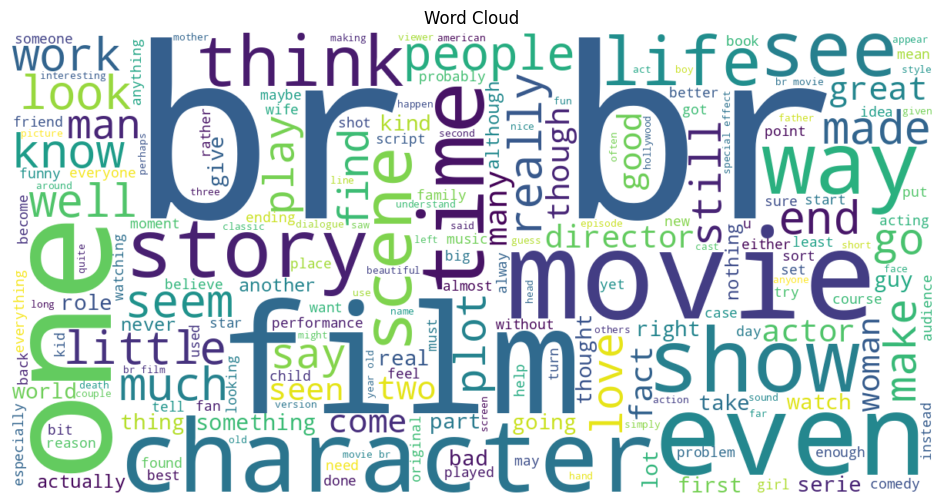

In [25]:
all_words = ' '.join(train_df['clean_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200
).generate(all_words)

plt.figure(figsize=(15,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Word Cloud')

plt.show()

Most Frequent Words

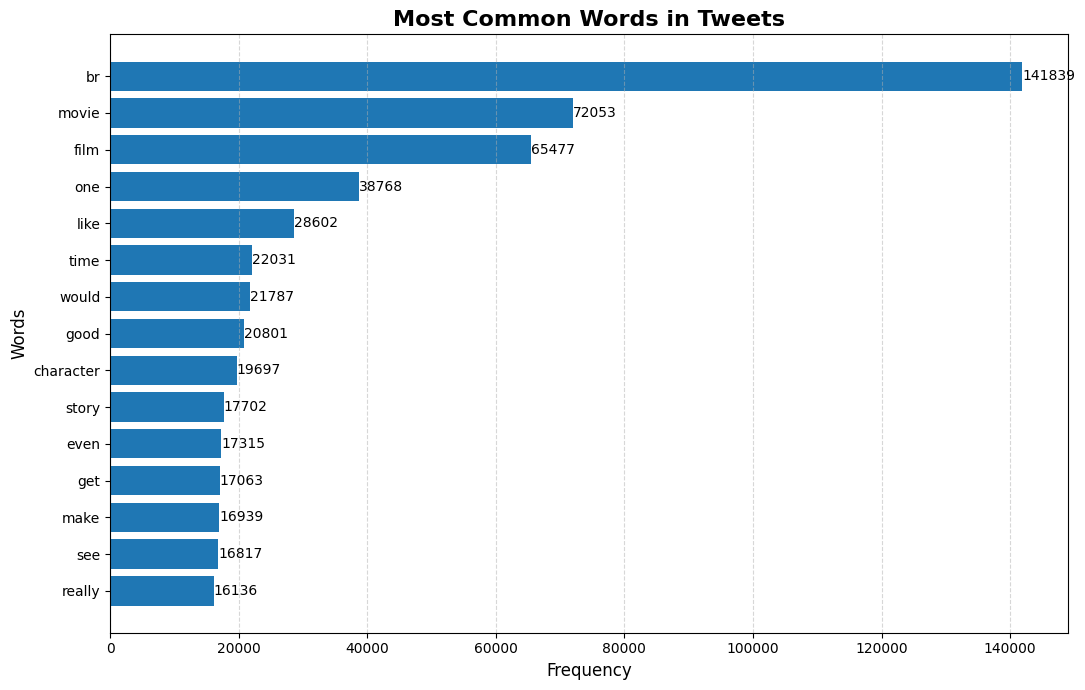

In [26]:
from collections import Counter

words = all_words.split()

word_freq = Counter(words)

common_words = word_freq.most_common(15)

words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(11,7))

bars = plt.barh(
    words_df['Word'],
    words_df['Frequency']
)

plt.gca().invert_yaxis()

plt.xlabel('Frequency', fontsize=12)

plt.ylabel('Words', fontsize=12)

plt.title(
    'Most Common Words in Tweets',
    fontsize=16,
    fontweight='bold'
)

# Add values beside bars
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        str(int(width)),
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

Tokenization

In [59]:
max_words = 20000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(train_df['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])

X_val_seq = tokenizer.texts_to_sequences(val_df['clean_text'])

X_test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])

Padding

In [68]:
sequence_lengths = [len(seq) for seq in X_train_seq]

max_length = int(np.percentile(sequence_lengths, 95))

print("Padding Length:", max_length)

X_train = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_val = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding='post'
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

Padding Length: 316


Prepare Lebels

In [29]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df['label'])

y_val = encoder.transform(val_df['label'])

y_test = encoder.transform(test_df['label'])

print(encoder.classes_)

[0 1]


Vocabularu size

In [30]:
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 77223


Early Stopping

In [31]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

MODEL 1 (Simple RNN)

In [32]:
embedding_dim = 128

model_rnn = Sequential()

model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
)

model_rnn.add(SimpleRNN(64))

model_rnn.add(Dropout(0.5))

model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train RNN Model

In [34]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5058 - loss: 0.6984 - val_accuracy: 0.4942 - val_loss: 0.6936
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.5138 - loss: 0.6920 - val_accuracy: 0.4952 - val_loss: 0.6932
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.5146 - loss: 0.6910 - val_accuracy: 0.4962 - val_loss: 0.6954
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.5257 - loss: 0.6829 - val_accuracy: 0.5098 - val_loss: 0.6937
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.5222 - loss: 0.6782 - val_accuracy: 0.5098 - val_loss: 0.6955


Evaluate RNN

In [35]:
rnn_loss, rnn_acc = model_rnn.evaluate(X_test, y_test)

print("RNN Accuracy:", rnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5019 - loss: 0.6927
RNN Accuracy: 0.5019000172615051


MODEL 2 (LSTM)

In [36]:
model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
)

model_lstm.add(LSTM(64))

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train LSTM

In [37]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.5024 - loss: 0.6937 - val_accuracy: 0.4956 - val_loss: 0.6930
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5065 - loss: 0.7006 - val_accuracy: 0.5174 - val_loss: 0.6916
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5181 - loss: 0.6847 - val_accuracy: 0.5070 - val_loss: 0.6847
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5206 - loss: 0.6720 - val_accuracy: 0.5058 - val_loss: 0.6904
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5245 - loss: 0.6630 - val_accuracy: 0.5028 - val_loss: 0.6992
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5338 - loss: 0.6592 - val_accuracy: 0.5046 - val_loss: 0.7111


Evaluate LSTM

In [38]:
lstm_loss, lstm_acc = model_lstm.evaluate(X_test, y_test)

print("LSTM Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5107 - loss: 0.6859
LSTM Accuracy: 0.510699987411499


Plot RNN Accuracy Graph

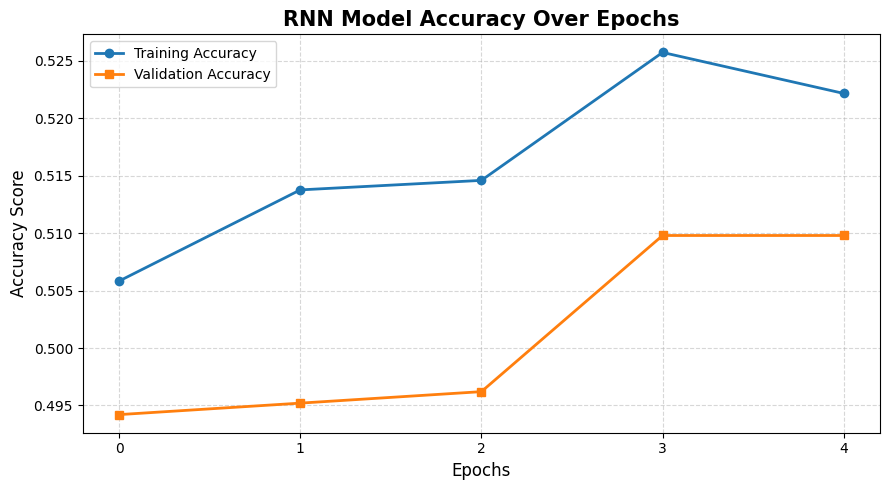

In [39]:
plt.figure(figsize=(9,5))

plt.plot(
    history_rnn.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    history_rnn.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title(
    'RNN Model Accuracy Over Epochs',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Epochs', fontsize=12)

plt.ylabel('Accuracy Score', fontsize=12)

plt.xticks(range(len(history_rnn.history['accuracy'])))

plt.grid(
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.tight_layout()

plt.show()

Plot RNN Loss Graph

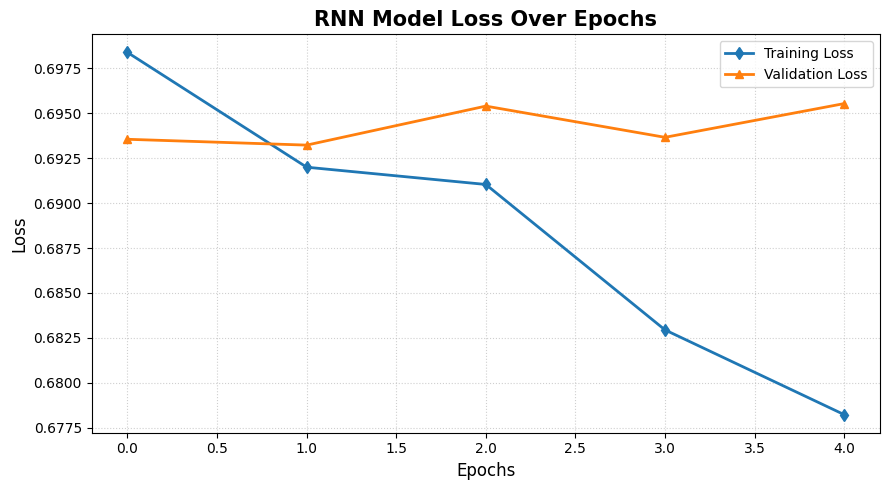

In [40]:
plt.figure(figsize=(9,5))

plt.plot(
    history_rnn.history['loss'],
    marker='d',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    history_rnn.history['val_loss'],
    marker='^',
    linewidth=2,
    label='Validation Loss'
)

plt.title(
    'RNN Model Loss Over Epochs',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Epochs', fontsize=12)

plt.ylabel('Loss', fontsize=12)

plt.grid(
    linestyle=':',
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.show()

Plot LSTM Accuracy

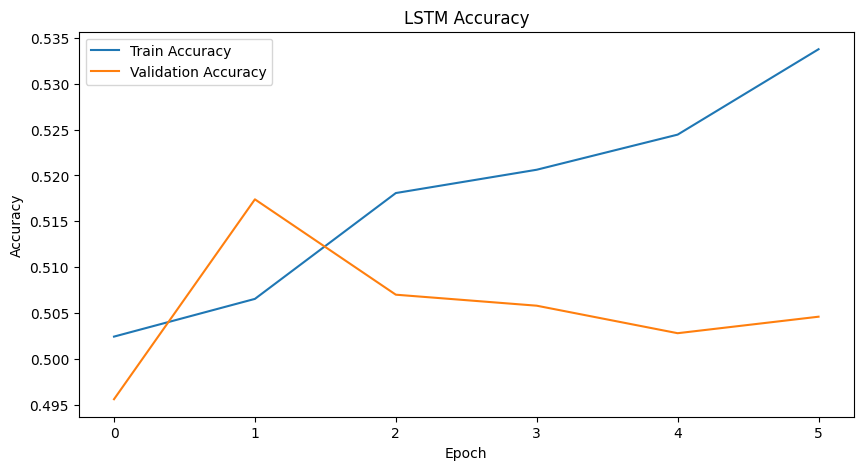

In [41]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')

plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title('LSTM Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

Plot LSTM Loss

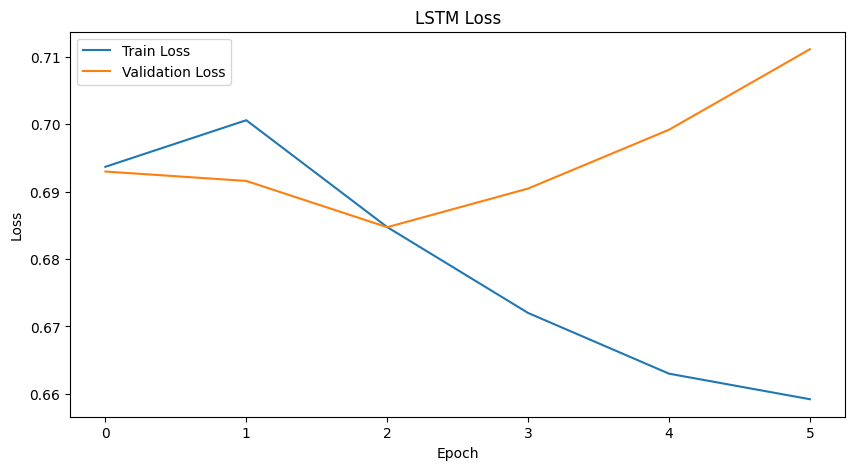

In [42]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Train Loss')

plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('LSTM Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

Compare RNN vs LSTM Accuracy

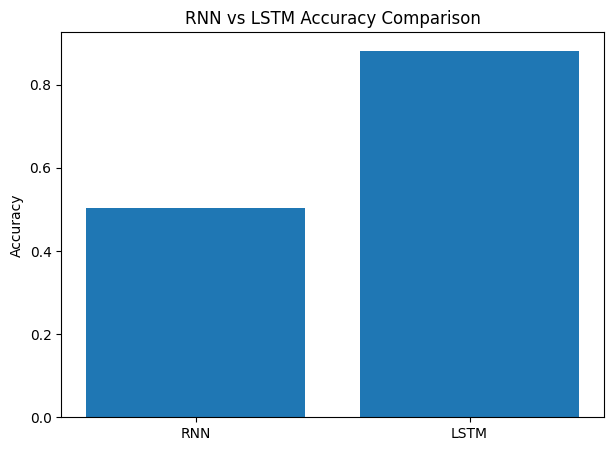

In [45]:
models = ['RNN', 'LSTM']

accuracies = [rnn_acc, lstm_acc]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.ylabel('Accuracy')

plt.title('RNN vs LSTM Accuracy Comparison')

plt.show()

Confusion Matrix for LSTM

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


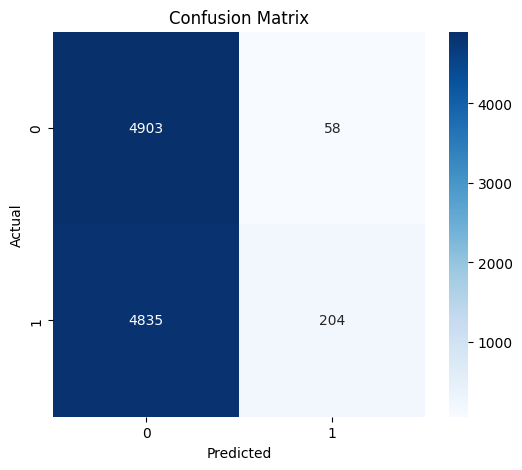

In [43]:
predictions = model_lstm.predict(X_test)

predictions = (predictions > 0.5).astype(int)

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

Classification Report

In [44]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.50      0.99      0.67      4961
           1       0.78      0.04      0.08      5039

    accuracy                           0.51     10000
   macro avg       0.64      0.51      0.37     10000
weighted avg       0.64      0.51      0.37     10000



Error Analysis

In [45]:
predictions_flat = predictions.flatten()

incorrect_indices = np.where(predictions_flat != y_test)[0]

print("Total Misclassified:", len(incorrect_indices))

Total Misclassified: 4893


Show Wrong Predictions

In [46]:
for i in incorrect_indices[:3]:

    print("\n======================")

    print("Original Review:\n")

    print(test_df.iloc[i]['text'])

    print("\nActual Label:", y_test[i])

    print("Predicted Label:", predictions_flat[i])


Original Review:

I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and the Headshrinkers, and Yo

LSTM with Pretrained Word2Vec Embeddings

In [50]:
!pip install numpy==1.23.5
!pip install gensim
!pip install jax==0.4.13

  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Using cached jax-0.4.13-py3-none-any.whl
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
optax 0.2.8 requires jaxlib>=0.5.3, which is not installed.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0

Install Compatible Gensim Version

In [ ]:
!pip install gensim==4.3.2

Import Genism

In [1]:
import gensim.downloader as api

print("Gensim Imported Successfully")

Gensim Imported Successfully


Load Pretrained Word2Vec

In [53]:
max_vocab_size = 12000

In [54]:
embedding_model = api.load('glove-wiki-gigaword-50')

Create Embedding Matrix

In [55]:
embedding_dim = 50

word_index = tokenizer.word_index

embedding_matrix = np.zeros(
    (max_vocab_size, embedding_dim)
)

for word, index in word_index.items():

    if index < max_vocab_size:

        if word in embedding_model:

            embedding_matrix[index] = embedding_model[word]

In [49]:
import nltk

In [50]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [65]:
X_train = X_train.astype(str)

X_test = X_test.astype(str)

Tokenizer Cell

In [73]:
max_vocab_size = 12000

# Convert into list of strings
X_train_text = [str(i) for i in X_train]

X_test_text = [str(i) for i in X_test]

tokenizer = Tokenizer(
    num_words=max_vocab_size,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)

test_sequences = tokenizer.texts_to_sequences(X_test_text)

padding

In [74]:
sequence_lengths = [
    len(seq)
    for seq in train_sequences
]

max_length = int(
    np.percentile(sequence_lengths, 90)
)

X_train_pad = pad_sequences(
    train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

Build Word2Vec LSTM Model

In [56]:
w2v_model = Sequential()

w2v_model.add(
    Embedding(
        input_dim=max_vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    )
)

w2v_model.add(
    LSTM(64)
)

w2v_model.add(Dropout(0.3))

w2v_model.add(
    Dense(32, activation='relu')
)

w2v_model.add(
    Dense(1, activation='sigmoid')
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile Model

In [57]:
w2v_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [77]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [78]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

Train Model

In [79]:
history_w2v = w2v_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5041 - loss: 0.6944 - val_accuracy: 0.4879 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5059 - loss: 0.6932 - val_accuracy: 0.5170 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5040 - loss: 0.6931 - val_accuracy: 0.4881 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5042 - loss: 0.6930 - val_accuracy: 0.5176 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5090 - loss: 0.6925 - val_accuracy: 0.5169 - val_loss: 0.6927 - learning_rate: 5.0000e-04


Accuracy Graph

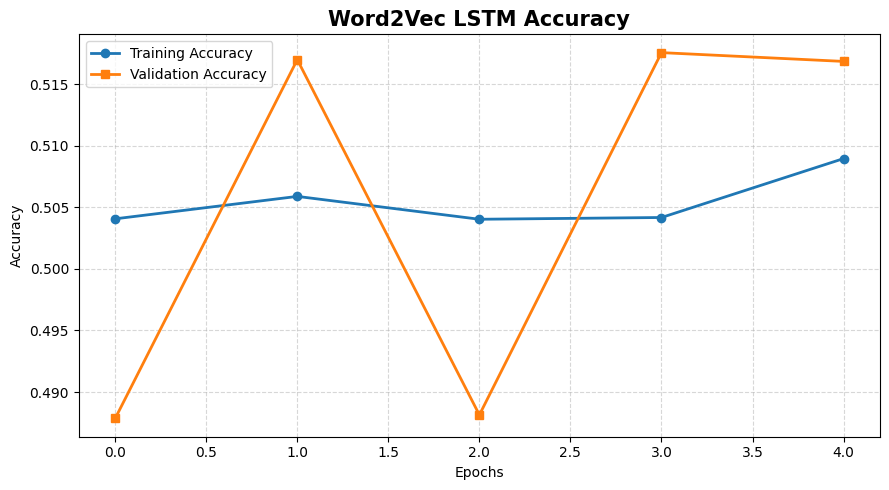

In [80]:
plt.figure(figsize=(9,5))

plt.plot(
    history_w2v.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    history_w2v.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title(
    'Word2Vec LSTM Accuracy',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.grid(
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.tight_layout()

plt.show()

Loss Graph

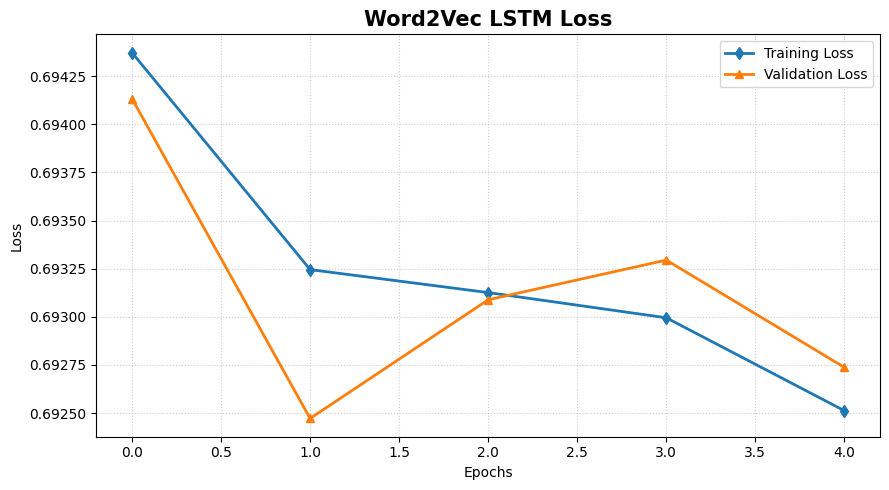

In [81]:
plt.figure(figsize=(9,5))

plt.plot(
    history_w2v.history['loss'],
    marker='d',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    history_w2v.history['val_loss'],
    marker='^',
    linewidth=2,
    label='Validation Loss'
)

plt.title(
    'Word2Vec LSTM Loss',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.grid(
    linestyle=':',
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.show()

Evaluate Model

In [82]:
w2v_loss, w2v_acc = w2v_model.evaluate(
    X_test_pad,
    y_test
)

print('Word2Vec LSTM Accuracy:', w2v_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5006 - loss: 0.6936
Word2Vec LSTM Accuracy: 0.5005999803543091


Predictions

In [83]:
w2v_pred_prob = w2v_model.predict(X_test_pad)

w2v_predictions = (
    w2v_pred_prob > 0.5
).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


Confusion Matrix

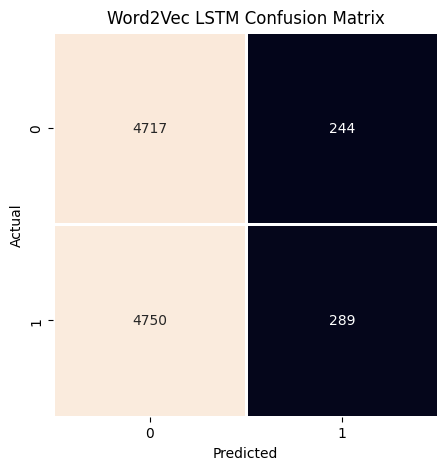

In [84]:
cm = confusion_matrix(
    y_test,
    w2v_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    linewidths=2,
    square=True,
    cbar=False
)

plt.title('Word2Vec LSTM Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

Classification Report

In [85]:
print(
    classification_report(
        y_test,
        w2v_predictions
    )
)

              precision    recall  f1-score   support

           0       0.50      0.95      0.65      4961
           1       0.54      0.06      0.10      5039

    accuracy                           0.50     10000
   macro avg       0.52      0.50      0.38     10000
weighted avg       0.52      0.50      0.38     10000



Model Comparison Table

In [86]:
comparison_df = pd.DataFrame({

    'Model': [
        'SimpleRNN',
        'LSTM',
        'Word2Vec LSTM'
    ],

    'Accuracy': [
        rnn_acc,
        lstm_acc,
        w2v_acc
    ]
})

comparison_df

,Model,Accuracy
0,SimpleRNN,0.5019
1,LSTM,0.5107
2,Word2Vec LSTM,0.5006


Comparison Graph

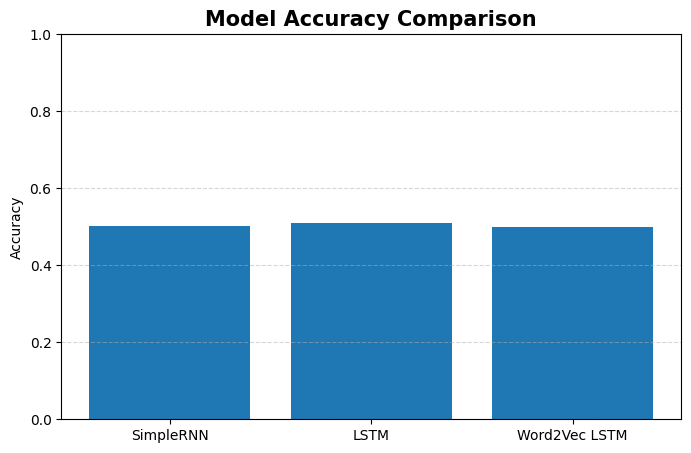

In [87]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Accuracy']
)

plt.title(
    'Model Accuracy Comparison',
    fontsize=15,
    fontweight='bold'
)

plt.ylabel('Accuracy')

plt.ylim(0,1)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

Error Analysis

Find Incorrect Predictions

In [88]:
incorrect_indices = np.where(
    w2v_predictions.flatten() != y_test
)[0]

Display Misclassified Examples

In [91]:
for i in incorrect_indices[:3]:

    print('Tweet Sequence:')
    print(X_test[i])

    print('\nActual Label:')
    print(y_test[i])

    print('\nPredicted Label:')
    print(w2v_predictions[i][0])

    print('\n' + '='*60 + '\n')

Tweet Sequence:
[   16   319     1   560    45  8248  5813    45   326   125   140  3145
    20     5    47     1    49 10346  8282     1   181   407     1     7
   452   519  1574    50   781   451    50  1138     7  1021   277   181
   407     6    81   759     1   277   759  1914  5333  7422   781  2399
 11017  9377   298   781  9312   416  6300   362   781 16561     1   407
  6300   641   103   453   416  1825  9843 13954   781   130 12283  3537
    25    52     1    52  1524     1   417  3537     1   119   125     1
     1  2429  3885     1  7323   438  1063     1    76   277   759  2856
     1     1   438  4685  4685 14083     1     1 14456    84   275  8282
     1   759   249   277   167   101   837     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     

Add Markdown Discussion

# Observations from Error Analysis

Some tweets were incorrectly classified because of:

- Presence of sarcasm or irony.
- Very short tweets with limited context.
- Informal language and spelling variations.
- Mixed sentiment within the same sentence.

The model may also struggle with emojis, abbreviations, and unseen words that were not present during training.

Add Improvement Suggestions

## Suggestions for Future Improvements

Several improvements can be made to further enhance the performance of the sentiment analysis model:

- Increase the dataset size to improve generalization.
- Use Bidirectional LSTM for better contextual understanding.
- Fine-tune pretrained embeddings instead of freezing them.
- Apply advanced preprocessing techniques such as emoji handling and slang normalization.
- Perform hyperparameter tuning for batch size, learning rate, and embedding dimensions.
- Use transformer-based architectures such as BERT or RoBERTa for improved semantic understanding.

These improvements may help reduce misclassification and improve overall model accuracy.

Gui

Real-Time Prediction GUI using Gradio

Install Gradio

In [92]:
!pip install gradio

Import gradio

In [93]:
import gradio as gr

Prediction Function

In [94]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    prediction = w2v_model.predict(padded)[0][0]

    if prediction >= 0.5:
        return "Positive Sentiment"

    else:
        return "Negative Sentiment"

Create Interface

In [99]:
interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a tweet here..."
    ),
    outputs="text",
    title="Tweet Sentiment Analyzer",
    description="Predict sentiment using Word2Vec + LSTM model"
)

Launch GUI

In [100]:
interface.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ae893fe7b4d03da98d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ae893fe7b4d03da98d.gradio.live
